# Exercise 1.  Population structure analysis using SNPs
### Dataset

https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/data_collections/1000_genomes_project/release/20181203_
biallelic_SNV/

The SNV genotypes are made available in VCF files for each chromosome. You can start with SNV on chr1.

### Workflow

VCF file   --   PLINK convert  --  LD Pruning  --  PCA analysis  -- ADMIXTURE Analysis 

### Reading 

https://link.springer.com/protocol/10.1007/978-1-0716-0199-0_4 
https://connor-french.github.io/intro-pop-structure-r/  

### PLINK convert

#i ran these directly in terminal becasue of some path problesm, sorry for the layout


In [ ]:
!cd ~/BIO392/20260429/00_data

#!mv ./ALL.chr1.shapeit2_integrated_v1a.GRCh38.20181129.phased.vcf.gz chr1.vcf.gz

!plink --vcf ./chr1.vcf.gz  --make-bed --out chr1

output:

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to chr1.log.
Options in effect:
  --make-bed
  --out chr1
  --vcf ./chr1.vcf.gz

13796 MB RAM detected; reserving 6898 MB for main workspace.
--vcf: chr1-temporary.bed + chr1-temporary.bim + chr1-temporary.fam written.
5795045 variants loaded from .bim file.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to chr1.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... done.
Total genotyping rate is exactly 1.
5795045 variants and 2548 people pass filters and QC.
Note: No phenotypes present.
--make-bed to chr1.bed + chr1.bim + chr1.fam ... done.


-->


rename the variant ids with their locus (now they are all called '.')

In [ ]:
!plink --vcf ./chr1.vcf.gz \
    --set-missing-var-ids @:# \
    --make-bed \
    --out chr1_ids \
    --allow-extra-chr

output: 
13796 MB RAM detected; reserving 6898 MB for main workspace.
--vcf: chr1_ids-temporary.bed + chr1_ids-temporary.bim + chr1_ids-temporary.fam
written.
5795045 variants loaded from .bim file.
5795045 missing IDs set.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to chr1_ids.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... done.
Total genotyping rate is exactly 1.
5795045 variants and 2548 people pass filters and QC.
Note: No phenotypes present.
--make-bed to chr1_ids.bed + chr1_ids.bim + chr1_ids.fam ... done.

rename the variant ids with their locus (now they are all called '.')



In [ ]:
!plink --vcf ./chr1.vcf.gz \
    --set-missing-var-ids @:# \
    --make-bed \
    --out chr1_ids \
    --allow-extra-chr

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to chr1_ids.log.
Options in effect:
  --allow-extra-chr
  --make-bed
  --out chr1_ids
  --set-missing-var-ids @:#
  --vcf ./chr1.vcf.gz

13796 MB RAM detected; reserving 6898 MB for main workspace.
--vcf: chr1_ids-temporary.bed + chr1_ids-temporary.bim + chr1_ids-temporary.fam
written.
5795045 variants loaded from .bim file.
5795045 missing IDs set.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to chr1_ids.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... done.
Total genotyping rate is exactly 1.
5795045 variants and 2548 people pass filters and QC.
Note: No phenotypes present.
--make-bed to chr1_ids.bed + chr1_ids.bim + chr1_ids.fam ... done.

### LD-pruning

using same window, r2 like in the paper

In [ ]:
!ls

In [ ]:
!plink --bfile chr1_ids \
    --extract chr1_pruned.prune.in \
    --make-bed \
    --out chr1_LDpruned \
    --allow-extra-chr

output:

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to chr1_pruned.log.
Options in effect:
  --allow-extra-chr
  --bfile chr1_ids
  --indep-pairwise 50 10 0.1
  --out chr1_pruned

13796 MB RAM detected; reserving 6898 MB for main workspace.
5795045 variants loaded from .bim file.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to chr1_pruned.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... done.
Total genotyping rate is exactly 1.
5795045 variants and 2548 people pass filters and QC.
Note: No phenotypes present.
Pruned 1215623 variants from chromosome 1, leaving 4579422.
Pruning complete.  1215623 of 5795045 variants removed.
Marker lists written to chr1_pruned.prune.in and chr1_pruned.prune.out 

In [ ]:
!plink --bfile chr1_ids \
    --extract chr1_pruned.prune.in \
    --make-bed \
    --out chr1_LDpruned \
    --allow-extra-chr

13796 MB RAM detected; reserving 6898 MB for main workspace.
5795045 variants loaded from .bim file.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to chr1_LDpruned.nosex .
--extract: 4579422 variants remaining.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... done.
Total genotyping rate is exactly 1.
4579422 variants and 2548 people pass filters and QC.
Note: No phenotypes present.
--make-bed to chr1_LDpruned.bed + chr1_LDpruned.bim + chr1_LDpruned.fam ...
done.

(human_env) francesco@ThinkPadT14:~/BIO392/20260429/00_data$ wc -l chr1_LDpruned.bim
4579422 chr1_LDpruned.bim
(human_env) francesco@ThinkPadT14:~/BIO392/20260429/00_data$ wc -l chr1.bim
5795045 chr1.bim

seems like 12'000 snps were filtered out

In [ ]:
!plink --bfile chr1_LDpruned \
    --pca 10 \
    --out chr1_pca \
    --allow-extra-chr

output:

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to chr1_pca.log.
Options in effect:
  --allow-extra-chr
  --bfile chr1_LDpruned
  --out chr1_pca
  --pca 10

13796 MB RAM detected; reserving 6898 MB for main workspace.
4579422 variants loaded from .bim file.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to chr1_pca.nosex .
Using up to 15 threads (change this with --threads).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... done.
Total genotyping rate is exactly 1.
4579422 variants and 2548 people pass filters and QC.
Note: No phenotypes present.
Relationship matrix calculation complete.
--pca: Results saved to chr1_pca.eigenval and chr1_pca.eigenvec .

visualize pca

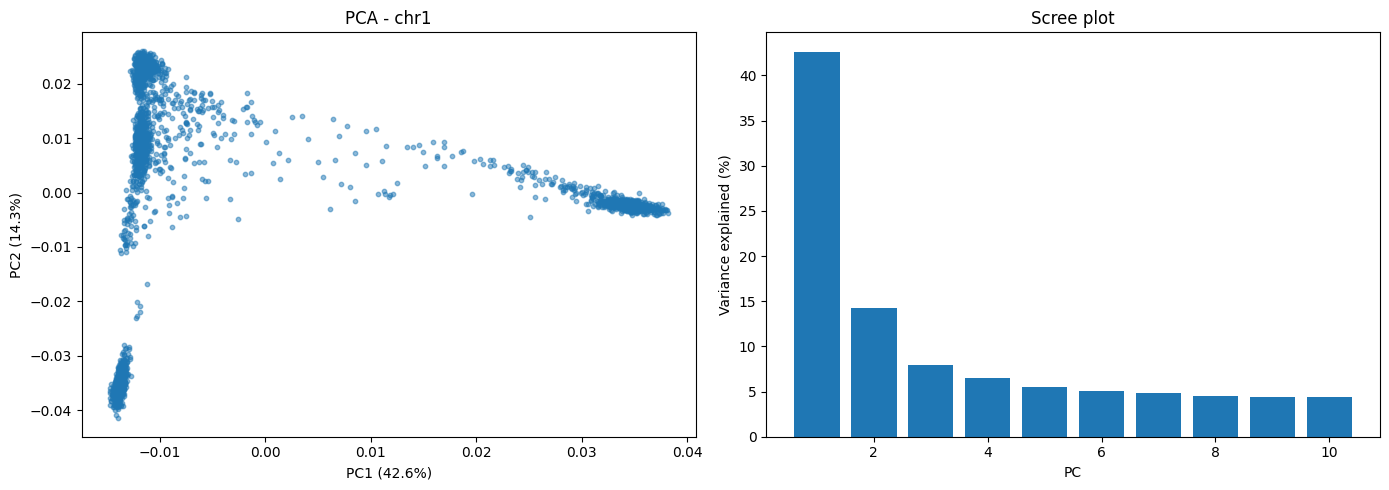

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

datadir = '../00_data/'

eigenvec = pd.read_csv(datadir + 'chr1_pca.eigenvec', sep=' ', header=None)
eigenval = pd.read_csv(datadir +'chr1_pca.eigenval', header=None)

eigenvec.columns = ['FID', 'IID'] + [f'PC{i}' for i in range(1, len(eigenvec.columns)-1)]


eigenval.columns = ['value']
eigenval['variance_explained'] = eigenval['value'] / eigenval['value'].sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(eigenvec['PC1'], eigenvec['PC2'], alpha=0.5, s=10)
axes[0].set_xlabel(f"PC1 ({eigenval['variance_explained'][0]:.1f}%)")
axes[0].set_ylabel(f"PC2 ({eigenval['variance_explained'][1]:.1f}%)")
axes[0].set_title('PCA - chr1')

# Bar plot
axes[1].bar(range(1, len(eigenval)+1), eigenval['variance_explained'])
axes[1].set_xlabel('PC')
axes[1].set_ylabel('Variance explained (%)')
axes[1].set_title('Scree plot')

plt.tight_layout()
plt.savefig('pca_plot.png', dpi=150)
plt.show()


PC1 has by far the most variance explained :)
but PC2 shows at least two distinct clusters on the scatter plot (if one focuses only on y axis)

it would actually be interesting to include metadata in the pca visualisation. Asked Feifei and she said no, (but i would expect that origin of samples and their position in the pca scatterplot would noticable as clusters)

### Admixture analysis
i will filter randomly only 10'000 snp's (pleas tell us things like that earlier than 4pm after a day of waiting for computing, many of us had to stay late or finish at the weekend because we did not know we need to reduce the amount of SNP's)


In [ ]:
plink --bfile chr1_LDpruned \
    --thin-count 10000 \
    --make-bed \
    --out chr1_LDpruned_thin \
    --allow-extra-chr

In [ ]:
admixture -j10 ./chr1_LDpruned_thin.bed 5 | tee log_K5.txt

output: 

****                   ADMIXTURE Version 1.3.0                  ****
****                    Copyright 2008-2015                     ****
****           David Alexander, Suyash Shringarpure,            ****
****                John  Novembre, Ken Lange                   ****
****                                                            ****
****                 Please cite our paper!                     ****
****   Information at www.genetics.ucla.edu/software/admixture  ****

Parallel execution requested.  Will use 10 threads.
Random seed: 43
Point estimation method: Block relaxation algorithm
Convergence acceleration algorithm: QuasiNewton, 3 secant conditions
Point estimation will terminate when objective function delta < 0.0001
Estimation of standard errors disabled; will compute point estimates only.
Size of G: 2548x10000
Performing five EM steps to prime main algorithm
1 (EM) 	Elapsed: 2.331	Loglikelihood: -1.34627e+06	(delta): 3.74025e+07
2 (EM) 	Elapsed: 2.771	Loglikelihood: -1.22691e+06	(delta): 119356
3 (EM) 	Elapsed: 1.243	Loglikelihood: -1.21699e+06	(delta): 9923.1
4 (EM) 	Elapsed: 2.418	Loglikelihood: -1.21143e+06	(delta): 5557.11
5 (EM) 	Elapsed: 2.573	Loglikelihood: -1.20744e+06	(delta): 3998.19
Initial loglikelihood: -1.20744e+06
Starting main algorithm
1 (QN/Block) 	Elapsed: 6.963	Loglikelihood: -1.12428e+06	(delta): 83151.5
2 (QN/Block) 	Elapsed: 6.059	Loglikelihood: -1.08419e+06	(delta): 40096.5
3 (QN/Block) 	Elapsed: 6.254	Loglikelihood: -1.06598e+06	(delta): 18210.6
4 (QN/Block) 	Elapsed: 5.749	Loglikelihood: -1.05617e+06	(delta): 9809.48
5 (QN/Block) 	Elapsed: 7.192	Loglikelihood: -1.05374e+06	(delta): 2425.76
6 (QN/Block) 	Elapsed: 6.785	Loglikelihood: -1.05335e+06	(delta): 389.586
7 (QN/Block) 	Elapsed: 6.249	Loglikelihood: -1.05331e+06	(delta): 43.9856
8 (QN/Block) 	Elapsed: 6.863	Loglikelihood: -1.0533e+06	(delta): 5.33256
9 (QN/Block) 	Elapsed: 5.215	Loglikelihood: -1.0533e+06	(delta): 1.50989
10 (QN/Block) 	Elapsed: 7.18	Loglikelihood: -1.0533e+06	(delta): 0.189673
11 (QN/Block) 	Elapsed: 6.59	Loglikelihood: -1.0533e+06	(delta): 0.0757209
12 (QN/Block) 	Elapsed: 6.226	Loglikelihood: -1.0533e+06	(delta): 0.0498733
13 (QN/Block) 	Elapsed: 6.504	Loglikelihood: -1.0533e+06	(delta): 0.0130728
14 (QN/Block) 	Elapsed: 8.966	Loglikelihood: -1.0533e+06	(delta): 0.00651499
15 (QN/Block) 	Elapsed: 7.959	Loglikelihood: -1.0533e+06	(delta): 0.00442876
16 (QN/Block) 	Elapsed: 7.882	Loglikelihood: -1.0533e+06	(delta): 0.00439069
17 (QN/Block) 	Elapsed: 5.847	Loglikelihood: -1.0533e+06	(delta): 0.00434023
18 (QN/Block) 	Elapsed: 6.69	Loglikelihood: -1.0533e+06	(delta): 0.00424466
19 (QN/Block) 	Elapsed: 7.308	Loglikelihood: -1.0533e+06	(delta): 0.00411009
20 (QN/Block) 	Elapsed: 6.571	Loglikelihood: -1.0533e+06	(delta): 0.00394272
21 (QN/Block) 	Elapsed: 6.945	Loglikelihood: -1.0533e+06	(delta): 0.00375517
22 (QN/Block) 	Elapsed: 7.292	Loglikelihood: -1.0533e+06	(delta): 0.00356106
23 (QN/Block) 	Elapsed: 7.475	Loglikelihood: -1.0533e+06	(delta): 0.00337041
24 (QN/Block) 	Elapsed: 7.707	Loglikelihood: -1.0533e+06	(delta): 0.00317632
25 (QN/Block) 	Elapsed: 6.525	Loglikelihood: -1.0533e+06	(delta): 0.00280377
26 (QN/Block) 	Elapsed: 5.285	Loglikelihood: -1.0533e+06	(delta): 0.00264844
27 (QN/Block) 	Elapsed: 6.402	Loglikelihood: -1.0533e+06	(delta): 0.0036423
28 (QN/Block) 	Elapsed: 6.72	Loglikelihood: -1.0533e+06	(delta): 0.000219646
29 (QN/Block) 	Elapsed: 6.094	Loglikelihood: -1.0533e+06	(delta): 7.64001e-05
Summary: 
Converged in 29 iterations (213.537 sec)
Loglikelihood: -1053301.497175
Fst divergences between estimated populations: 
	Pop0	Pop1	Pop2	Pop3	
Pop0	
Pop1	0.134	
Pop2	0.091	0.106	
Pop3	0.079	0.106	0.036	
Pop4	0.073	0.133	0.100	0.069	
Writing output files.

In [ ]:
for K in 2 3 4 6; do
    admixture -j10 ./chr1_LDpruned_thin.bed $K | tee log_K${K}.txt
done

output: 

similar as before, way too long to show here

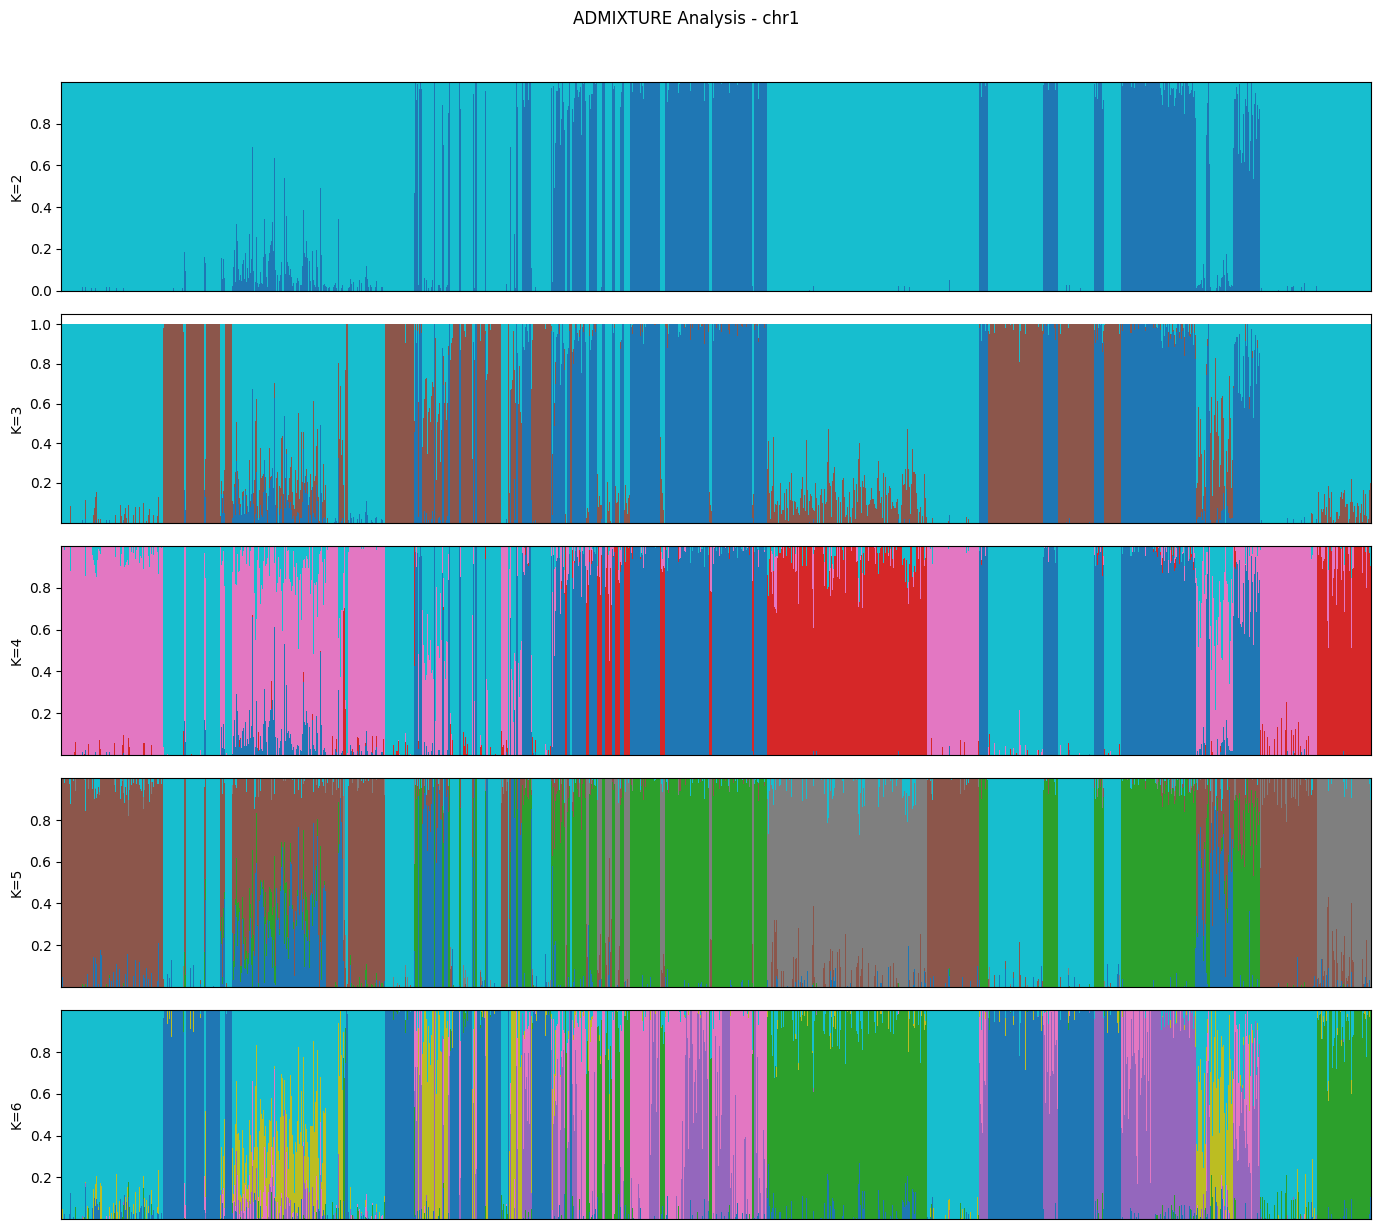

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

datadir = '../00_data/'

fig, axes = plt.subplots(5, 1, figsize=(14, 12))

for i, K in enumerate(range(2, 7)):
    Q = pd.read_csv(f'{datadir}chr1_LDpruned_thin.{K}.Q', 
                    sep=' ', header=None)
    Q.plot(kind='bar', stacked=True, ax=axes[i], 
           legend=False, width=1.0, colormap='tab10')
    axes[i].set_ylabel(f'K={K}')
    axes[i].set_xticks([])
    axes[i].set_xlim(-0.5, len(Q)-0.5)

plt.suptitle('ADMIXTURE Analysis - chr1', y=1.02)
plt.tight_layout()
plt.savefig('admixture_plot.png', dpi=150, bbox_inches='tight')
plt.show()

i think interpretation is hard without metadata of samples I SPECIFICALLY ASKED TWICE IF IT SHOULD BE INCLUDED (WOULD HAVE MADE SENSE TO ME), FEIFEI SAID NO, 
so here is a plot with no metadata

k=2: i guess the split in two is aftican/noonafrican, historically biggest split

k=3: maybe nonafrican split into europe and south asia if including historical knowledge

k=4: new distinct red group --> meaybe east asia

k = 5 maybe africa, europe, east asia, south asia and americas, probl quite meaniful split at k = 5

k=6: plot gets harder to interpret